# Sit. 2 — Colab: EDA + GeoVision-CLIP + **SAE** + validación

## Mapa del notebook

| Paso | Qué hace |
|------|----------|
| HF | Dataset **Slucu-0310/geovision-cali-sit2** (1350 pares, split 70/15/15) |
| EDA | Balance, correlaciones y **calidad** (SCL/NDVI) en `/content/eda_sit2/` |
| Diagnóstico | Tras entrenar: curvas JSON, Recall global/clase, z_img, peores 20 pares |
| Modelo | **RemoteCLIP** (`chendelong/RemoteCLIP`, `RemoteCLIP-ViT-B-32.pt`) + MiniLM + **2 SAE** |
| Train | **1 celda**: InfoNCE + SAE (~40 ép.); Recall@1/@5 en **val** |

**¿SAE?** Sí: autoencoder disperso en rama imagen y texto (MSE + L1), peso α=0.1.

**¿De dónde el visual?** Hugging Face → `hf_hub_download` → `load_state_dict` (método oficial ChenDelong). Solo se entrena adaptador 13→3, SAE, proyecciones y texto (RemoteCLIP congelado si `FREEZE_VISUAL=True`).


In [8]:
# @title Dependencias
%pip install -q huggingface_hub open_clip_torch zarr numcodecs pandas pyarrow numpy matplotlib seaborn scipy
%pip install -q torch torchvision pytorch-lightning transformers sentencepiece wandb tqdm
# RemoteCLIP (metodo oficial ChenDelong): pesos en chendelong/RemoteCLIP via hf_hub_download


In [9]:
# @title Hugging Face — descarga dataset
import os
from pathlib import Path

HF_REPO_ID = "Slucu-0310/geovision-cali-sit2"
DATA_DIR = Path("/content/dataset_sit2")
EDA_DIR = Path("/content/eda_sit2")
RUN_DIR = Path("/content/runs/sit2_clip_colab")
EDA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
except Exception:
    pass

from huggingface_hub import login, snapshot_download

if os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    local_dir=str(DATA_DIR),
    local_dir_use_symlinks=False,
)
print("Dataset en:", DATA_DIR)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Dataset en: /content/dataset_sit2


In [10]:
# @title Utilidades de lectura (inline)
from __future__ import annotations
import json
from typing import Any, Literal
import numpy as np
import pandas as pd
import zarr

SEED = 42
CLASES = [
    "contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
    "vegetacion_densa", "suelo_urbano",
]
BANDAS_S2 = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12","SCL"]
_IDX_RGB = {"B4": 3, "B3": 2, "B2": 1}
SplitName = Literal["train", "val", "test"]
NUMERIC_COLS = [
    "valid_ratio", "frac_nubes_scl", "frac_claros_scl", "frac_nodata_scl",
    "ndvi", "bsi", "no2", "so2", "o3",
]

def _zarr_store(path: str):
    try:
        return zarr.storage.LocalStore(path)
    except AttributeError:
        return zarr.DirectoryStore(path)

def open_tiles_zarr(zarr_path):
    p = str(zarr_path)
    try:
        root = zarr.open(p, mode="r")
    except Exception:
        root = zarr.open(_zarr_store(p), mode="r")
    if isinstance(root, zarr.Array):
        return root
    if "tiles" in root:
        return root["tiles"]
    for _, a in root.arrays():
        return a
    raise ValueError(p)

def compute_band_stats(zarr_path, n_sample=512, seed=SEED):
    rng = np.random.default_rng(seed)
    arr = open_tiles_zarr(zarr_path)
    n = int(arr.shape[0])
    idx = rng.choice(n, size=min(n_sample, n), replace=False)
    sample = np.stack([np.asarray(arr[i], dtype=np.float32) for i in idx])
    mean = sample.mean(axis=(0, 2, 3))
    std = np.maximum(sample.std(axis=(0, 2, 3)), 1e-3)
    return mean.astype("float32"), std.astype("float32")

def tile_to_rgb_uint8(tile_13hw, p_low=2, p_high=98):
    chans = []
    for b in ("B4", "B3", "B2"):
        x = tile_13hw[_IDX_RGB[b]].astype(np.float32)
        fin = x[np.isfinite(x)]
        lo, hi = (np.percentile(fin, [p_low, p_high]) if fin.size else (0, 1))
        if hi <= lo:
            hi = lo + 1
        chans.append((np.clip((x - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8))
    return np.stack(chans, axis=-1)

META_PATH = DATA_DIR / "metadatos.parquet"
ZARR_PATH = DATA_DIR / "tiles.zarr"
df = pd.read_parquet(META_PATH)
tiles_z = open_tiles_zarr(ZARR_PATH)
secuencias = json.loads((DATA_DIR / "secuencias.json").read_text(encoding="utf-8"))
resumen = json.loads((DATA_DIR / "resumen.json").read_text(encoding="utf-8"))
assert len(df) == int(tiles_z.shape[0])
print(f"Pares: {len(df)} | tiles: {tiles_z.shape}")


Pares: 1350 | tiles: (1350, 13, 64, 64)


## 1. EDA exhaustivo (informe)

Balance, estadísticas por clase, correlaciones y muestras visuales. Salidas en `EDA_DIR`.

=== Balance global ===
 clase
contaminacion_alta_NO2    270
contaminacion_alta_SO2    270
ozono_anomalo             270
vegetacion_densa          270
suelo_urbano              270
Name: n, dtype: int64

=== Balance por split ===
 clase  contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split                                                                  
test                       41                      40             41   
train                     189                     189            189   
val                        40                      41             40   

clase  suelo_urbano  vegetacion_densa  
split                                  
test             41                40  
train           189               189  
val              40                41  


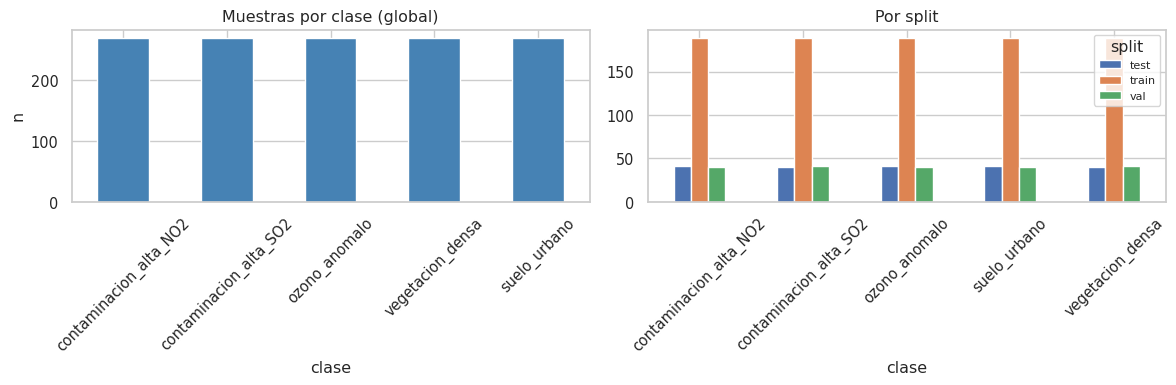


=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===
                            ndvi                                          \
                            mean       std       min       max    median   
clase                                                                      
contaminacion_alta_NO2  0.461044  0.188694 -0.004190  0.849206  0.486843   
contaminacion_alta_SO2  0.589377  0.137720  0.115653  0.853783  0.619091   
ozono_anomalo           0.576167  0.130698  0.157978  0.923665  0.583941   
suelo_urbano            0.469049  0.112686  0.130808  0.692492  0.488762   
vegetacion_densa        0.657285  0.083568  0.467241  0.927431  0.651071   

                             bsi                                          ...  \
                            mean       std       min       max    median  ...   
clase                                                                     ...   
contaminacion_alta_NO2 -0.069628  0.131066 -0.346122  0.227350 -0.066360  ...   
contamina

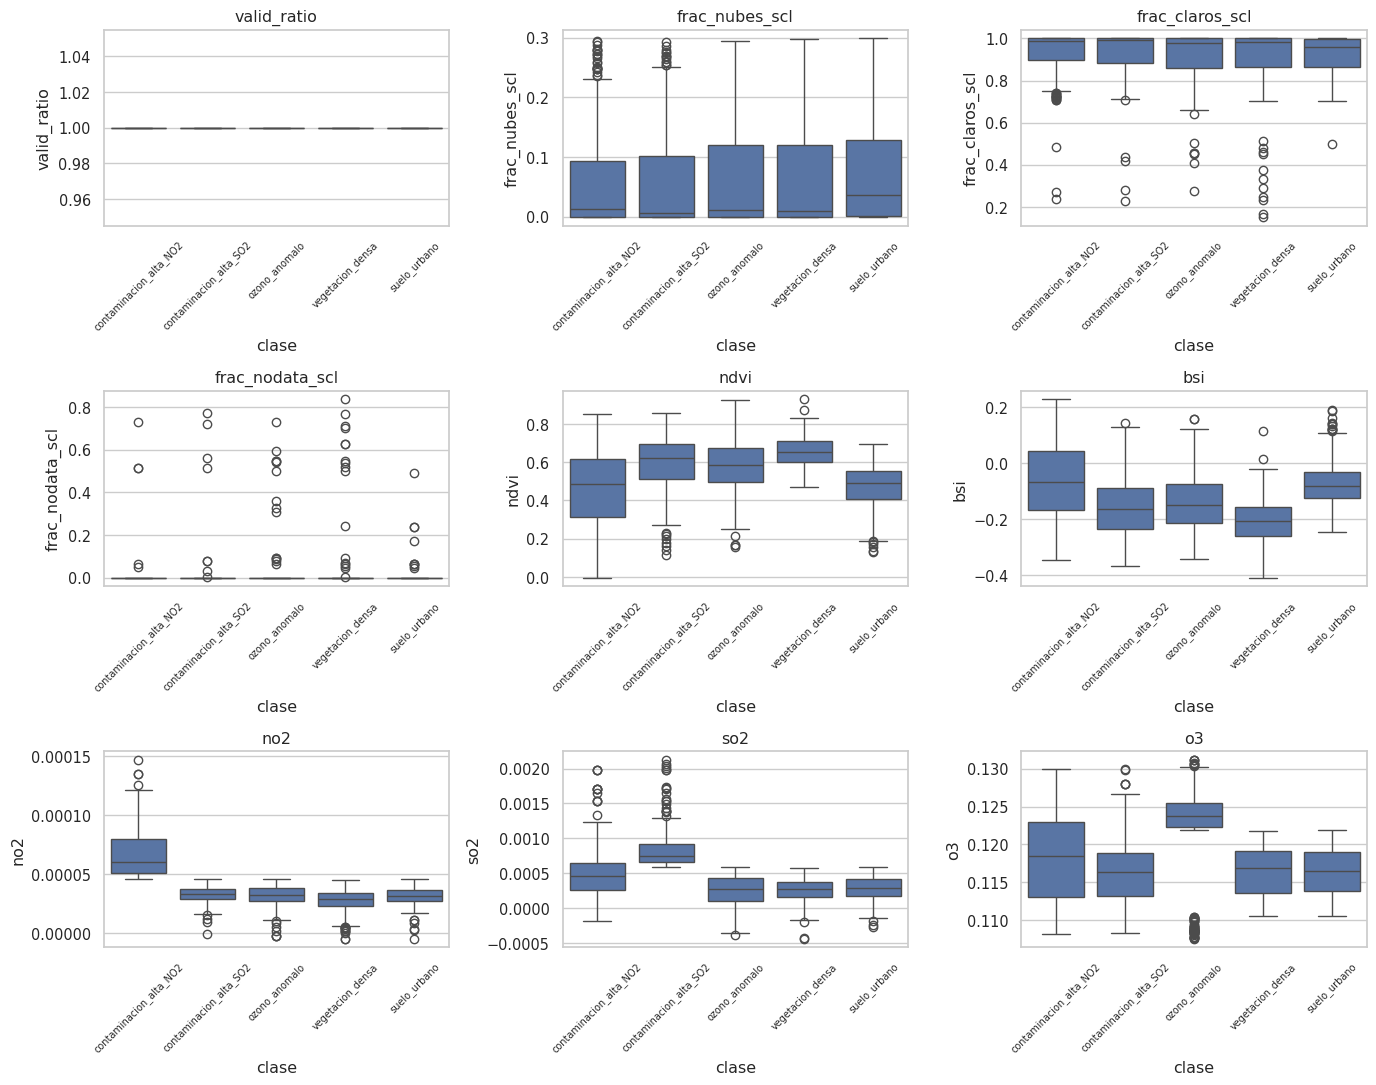

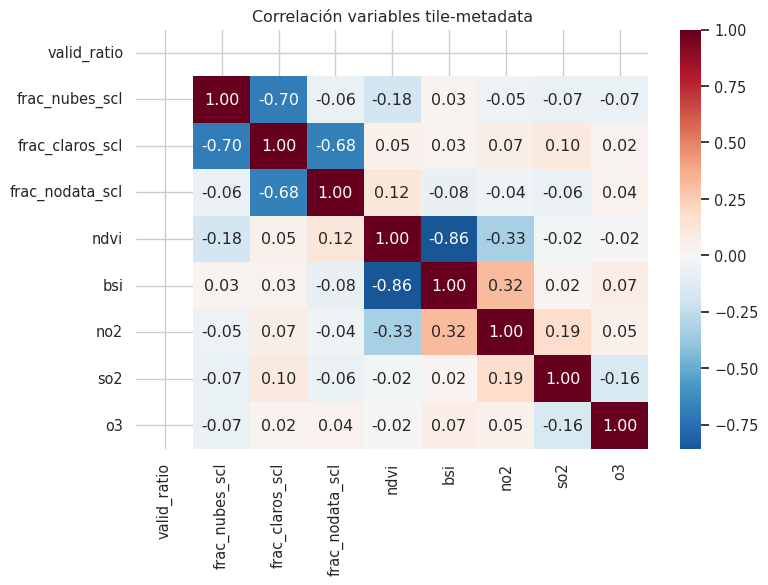

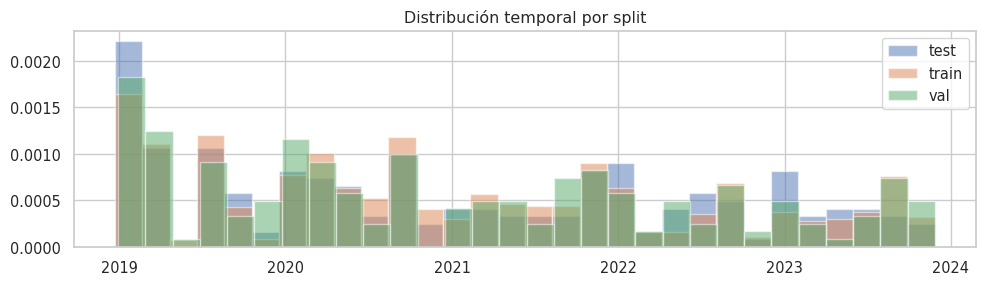

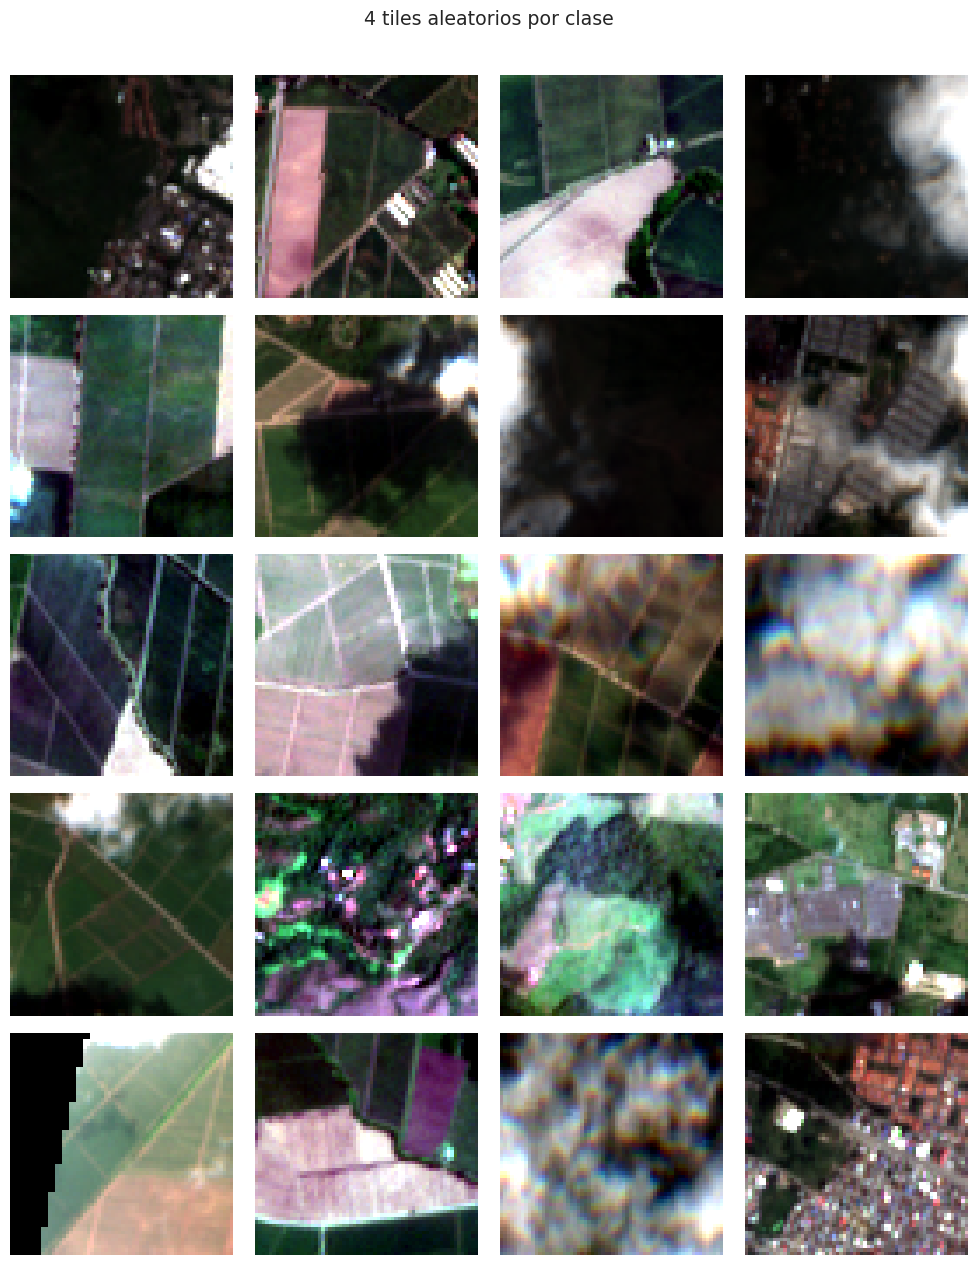


Secuencias: 30 | longitudes: [8, 8, 8, 8, 8]...
EDA guardado en: /content/eda_sit2


In [11]:
# @title EDA — tablas y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
rng = np.random.default_rng(SEED)

# --- Balance global y por split ---
bal_global = df["clase"].value_counts().reindex(CLASES).rename("n")
bal_global.to_csv(EDA_DIR / "balance_global.csv")
print("=== Balance global ===\n", bal_global)

bal_split = df.groupby(["split", "clase"]).size().unstack(fill_value=0)
bal_split.to_csv(EDA_DIR / "balance_por_split.csv")
print("\n=== Balance por split ===\n", bal_split)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bal_global.plot(kind="bar", ax=axes[0], color="steelblue", rot=45)
axes[0].set_title("Muestras por clase (global)")
axes[0].set_ylabel("n")
bal_split.T.plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("Por split")
axes[1].legend(title="split", fontsize=8)
plt.tight_layout()
plt.savefig(EDA_DIR / "01_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Estadísticas numéricas por clase ---
stats = df.groupby("clase")[NUMERIC_COLS].agg(["mean", "std", "min", "max", "median"])
stats.to_csv(EDA_DIR / "estadisticas_por_clase.csv")
print("\n=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===")
_cols_show = ["ndvi", "bsi", "frac_nubes_scl", "no2", "so2", "o3"]
# MultiIndex: nivel 0 = variable, nivel 1 = agregación (mean, std, ...)
print(stats.loc[:, pd.IndexSlice[_cols_show, :]].round(6))

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(data=df, x="clase", y=col, ax=axes[i], order=CLASES)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig(EDA_DIR / "02_boxplots_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Correlación (Pearson) ---
corr = df[NUMERIC_COLS].corr()
corr.to_csv(EDA_DIR / "correlacion_numericas.csv")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación variables tile-metadata")
plt.tight_layout()
plt.savefig(EDA_DIR / "03_correlacion.png", dpi=150)
plt.show()

# --- Fechas y splits ---
df["fecha_dt"] = pd.to_datetime(df["fecha"])
fig, ax = plt.subplots(figsize=(10, 3))
for sp, g in df.groupby("split"):
    ax.hist(g["fecha_dt"], bins=30, alpha=0.5, label=sp, density=True)
ax.legend()
ax.set_title("Distribución temporal por split")
plt.tight_layout()
plt.savefig(EDA_DIR / "04_fechas_por_split.png", dpi=150)
plt.show()

# --- Muestras RGB por clase ---
fig, axes = plt.subplots(len(CLASES), 4, figsize=(10, 2.5 * len(CLASES)))
for r, clase in enumerate(CLASES):
    sub = df[df["clase"] == clase]
    idxs = rng.choice(sub.index.to_numpy(), size=min(4, len(sub)), replace=False)
    for c, j in enumerate(idxs):
        tile = np.asarray(tiles_z[int(j)])
        axes[r, c].imshow(tile_to_rgb_uint8(tile))
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(clase, fontsize=8)
plt.suptitle("4 tiles aleatorios por clase", y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / "05_muestras_rgb_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Secuencias temporales (Sit. 3) ---
seq_lens = [len(s["tile_ids"]) for s in secuencias]
seq_df = pd.DataFrame({
    "n_secuencias": [len(secuencias)],
    "longitud_media": [np.mean(seq_lens)],
    "longitud_min": [min(seq_lens)],
    "longitud_max": [max(seq_lens)],
})
seq_df.to_csv(EDA_DIR / "resumen_secuencias.csv", index=False)
print(f"\nSecuencias: {len(secuencias)} | longitudes: {seq_lens[:5]}...")
print("EDA guardado en:", EDA_DIR)


## 2. EDA — calidad para entrenamiento

Informe complementario: nubes (SCL), claridad y NDVI por **split** y **clase**.
Salidas en `EDA_DIR` (`resumen_calidad_split_clase.csv`, `tiles_baja_calidad.csv`, paneles PNG).


### Paso 1 — Tabla resumen por split y clase

Mediana de `frac_nubes_scl`, `frac_claros_scl` y `ndvi` para detectar desbalance de calidad entre clases y splits.


In [12]:
# @title EDA calidad — Paso 1: mediana nubes / claros / NDVI
CALIDAD_COLS = ["frac_nubes_scl", "frac_claros_scl", "ndvi"]
rows = []
for split, gsp in df.groupby("split"):
    for clase in CLASES:
        sub = gsp[gsp["clase"] == clase]
        if sub.empty:
            continue
        row = {"split": split, "clase": clase, "n": len(sub)}
        for c in CALIDAD_COLS:
            row[f"mediana_{c}"] = float(sub[c].median())
        rows.append(row)
tab_calidad = pd.DataFrame(rows)
out_csv = EDA_DIR / "resumen_calidad_split_clase.csv"
tab_calidad.to_csv(out_csv, index=False)
print(tab_calidad.round(4).to_string(index=False))
print("\nGuardado:", out_csv)


split                  clase   n  mediana_frac_nubes_scl  mediana_frac_claros_scl  mediana_ndvi
 test contaminacion_alta_NO2  41                  0.0359                   0.9509        0.4879
 test contaminacion_alta_SO2  40                  0.0090                   0.9910        0.6111
 test          ozono_anomalo  41                  0.0396                   0.9341        0.5802
 test       vegetacion_densa  40                  0.0042                   0.9958        0.6610
 test           suelo_urbano  41                  0.0557                   0.9351        0.4849
train contaminacion_alta_NO2 189                  0.0059                   0.9932        0.4978
train contaminacion_alta_SO2 189                  0.0098                   0.9849        0.6215
train          ozono_anomalo 189                  0.0059                   0.9883        0.5768
train       vegetacion_densa 189                  0.0127                   0.9785        0.6483
train           suelo_urbano 189        

### Paso 2 — Tiles a revisar (baja calidad)

- Top **5%** con mayor `frac_nubes_scl` (peor nube).
- Outliers de NDVI por clase (|z-score| > 2.5).
Unión → `tiles_baja_calidad.csv`.


In [13]:
# @title EDA calidad — Paso 2: lista tiles_baja_calidad.csv
work = df.copy()
n_top = max(1, int(np.ceil(0.05 * len(work))))
top_nube = work.nlargest(n_top, "frac_nubes_scl").copy()
top_nube["motivo"] = "top5pct_frac_nubes"

outliers = []
for clase in CLASES:
    sub = work[work["clase"] == clase]
    if len(sub) < 8:
        continue
    mu, sig = sub["ndvi"].mean(), sub["ndvi"].std()
    if sig < 1e-9:
        continue
    z = (sub["ndvi"] - mu) / sig
    bad = sub.loc[z.abs() > 2.5].copy()
    bad["motivo"] = "outlier_ndvi_clase"
    outliers.append(bad)

lista = pd.concat([top_nube, *outliers], ignore_index=True)
lista = lista.drop_duplicates(subset=["tile_id"], keep="first")
cols_out = [
    "tile_id", "split", "clase", "motivo",
    "frac_nubes_scl", "frac_claros_scl", "ndvi", "valid_ratio", "descripcion",
]
lista = lista[[c for c in cols_out if c in lista.columns]]
out_lista = EDA_DIR / "tiles_baja_calidad.csv"
lista.to_csv(out_lista, index=False)
print(f"Tiles a revisar: {len(lista)} (top nube={len(top_nube)}, outliers NDVI={sum(len(o) for o in outliers)})")
print(lista.head(10).to_string(index=False))
print("\nGuardado:", out_lista)


Tiles a revisar: 92 (top nube=68, outliers NDVI=25)
                                             tile_id split                  clase             motivo  frac_nubes_scl  frac_claros_scl     ndvi  valid_ratio                                                                                                                                                                  descripcion
20220309T152641_20220309T152853_T18NUK__y0608__x3584 train           suelo_urbano top5pct_frac_nubes        0.298584         0.701416 0.552446          1.0     Tile Sentinel-2 sobre Cali con cobertura urbana de suelo expuesto (2022-03-09, lat=3.5925, lon=-76.3251, NDVI=0.55, BSI=-0.05, NO2=4.03e-05, SO2=5.42e-04, O3=1.14e-01).
20210617T152639_20210617T153208_T18NUJ__y2848__x3104 train       vegetacion_densa top5pct_frac_nubes        0.298096         0.701904 0.825246          1.0  Tile Sentinel-2 sobre Cali con vegetacion densa y baja contaminacion (2021-06-17, lat=3.3913, lon=-76.3683, NDVI=0.83, BSI=-0.16, NO2

### Paso 3 — Panel visual (RGB + SCL + histograma)

Muestra hasta **N** tiles de la lista de baja calidad (3 columnas: RGB, mapa SCL, histograma de bandas).


NameError: name '_IDX_SCL' is not defined

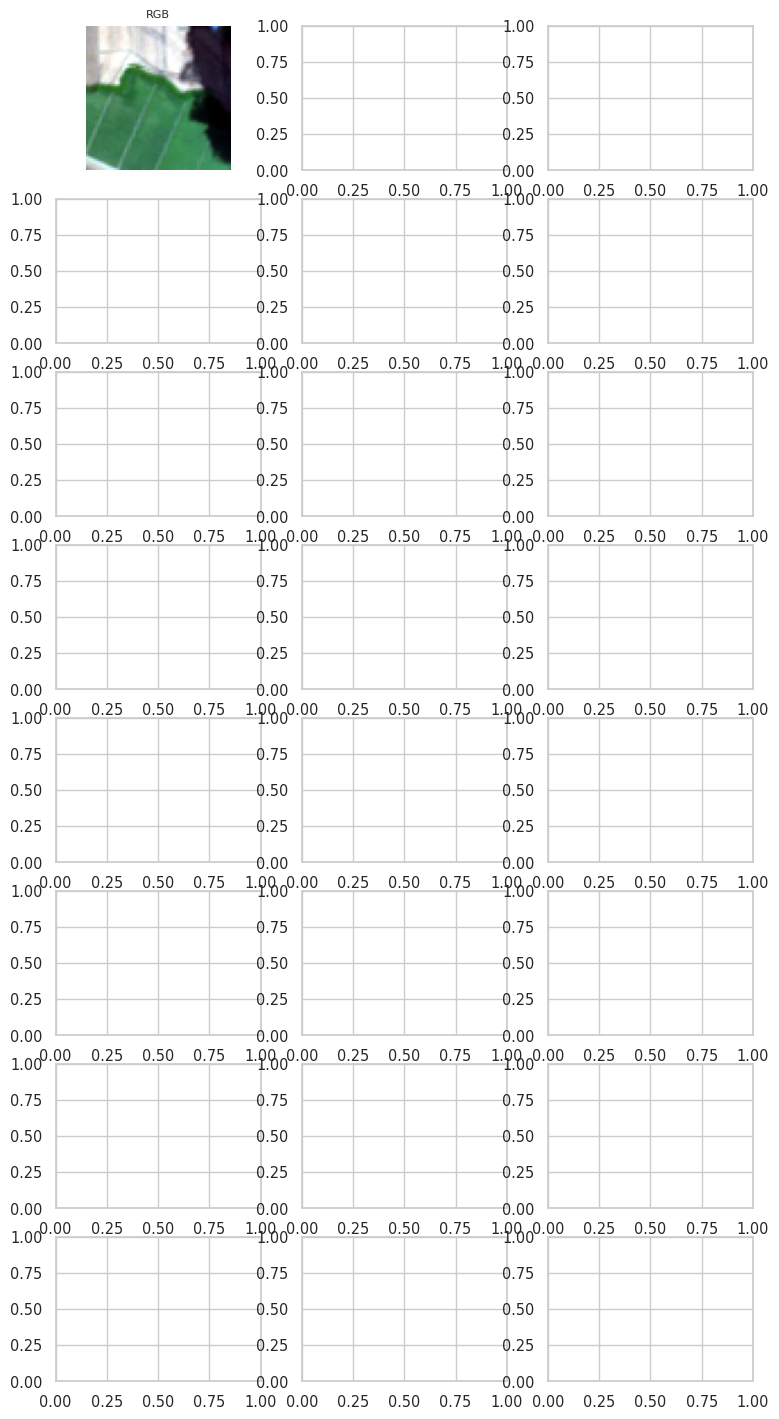

In [14]:
# @title EDA calidad — Paso 3: panel RGB + SCL + histograma
from matplotlib.colors import ListedColormap, BoundaryNorm

SCL_LABELS = {
    0: "nodata", 1: "saturado", 2: "sombra", 3: "nube", 4: "veg",
    5: "no_veg", 6: "agua", 7: "sin_clas", 8: "nube_med", 9: "cirrus",
    10: "nube_thin", 11: "nieve",
}
SCL_COLORS = [
    "#000000", "#ff0000", "#654321", "#cccccc", "#00aa00",
    "#ffff00", "#0000ff", "#808080", "#bbbbbb", "#00ffff",
    "#dddddd", "#ffffff",
]
_scl_cmap = ListedColormap(SCL_COLORS)
_scl_norm = BoundaryNorm(np.arange(-0.5, 12.5, 1), _scl_cmap.N)

def tile_scl_map(tile_13hw):
    scl = np.rint(tile_13hw[_IDX_SCL]).astype(np.int16)
    return scl

def plot_tile_panel(tile_13hw, title="", ax_rgb=None, ax_scl=None, ax_hist=None):
    if ax_rgb is not None:
        ax_rgb.imshow(tile_to_rgb_uint8(tile_13hw))
        ax_rgb.set_title("RGB", fontsize=8)
        ax_rgb.axis("off")
    if ax_scl is not None:
        scl = tile_scl_map(tile_13hw)
        im = ax_scl.imshow(scl, cmap=_scl_cmap, norm=_scl_norm, interpolation="nearest")
        ax_scl.set_title("SCL", fontsize=8)
        ax_scl.axis("off")
    if ax_hist is not None:
        vals = tile_13hw[:12].astype(np.float32).ravel()
        vals = vals[np.isfinite(vals)]
        ax_hist.hist(vals, bins=40, color="steelblue", alpha=0.85)
        ax_hist.set_title("hist bandas (sin SCL)", fontsize=8)
        ax_hist.set_xlabel("DN")
    if title and ax_rgb is not None:
        ax_rgb.set_ylabel(title, fontsize=7, rotation=0, labelpad=40, va="center")

_lista_path = EDA_DIR / "tiles_baja_calidad.csv"
if "lista" not in globals() and _lista_path.is_file():
    lista = pd.read_csv(_lista_path)
N_PANEL = min(8, len(lista)) if "lista" in globals() else 0
if N_PANEL == 0:
    print("Sin tiles en lista; ejecuta el Paso 2.")
else:
    fig, axes = plt.subplots(N_PANEL, 3, figsize=(9, 2.2 * N_PANEL))
    if N_PANEL == 1:
        axes = axes.reshape(1, -1)
    for r, (_, row) in enumerate(lista.head(N_PANEL).iterrows()):
        j = int(np.flatnonzero(df["tile_id"].values == row["tile_id"])[0])
        tile = np.asarray(tiles_z[j])
        ttl = f"{row['tile_id'][:12]}… | {row['clase'][:12]}"
        plot_tile_panel(tile, ttl, axes[r, 0], axes[r, 1], axes[r, 2])
    plt.suptitle("Tiles baja calidad — RGB / SCL / histograma", y=1.01)
    plt.tight_layout()
    out_png = EDA_DIR / "06_panel_calidad_rgb_scl_hist.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardado:", out_png)


### Paso 4 — Reglas de calidad “estricta”

Criterio estricto (más exigente que el pipeline por defecto):
- `frac_nubes_scl` ≤ 0.15
- `frac_claros_scl` ≥ 0.90

Se reporta el % de tiles que pasan, global y por split.


In [15]:
# @title EDA calidad — Paso 4: % pasa filtro estricto
UMBRAL_NUBE_ESTRICTO = 0.15
UMBRAL_CLAROS_ESTRICTO = 0.90

df["_pasa_estricto"] = (
    (df["frac_nubes_scl"] <= UMBRAL_NUBE_ESTRICTO)
    & (df["frac_claros_scl"] >= UMBRAL_CLAROS_ESTRICTO)
)
pct_global = 100.0 * df["_pasa_estricto"].mean()
resumen_estricto = {"ambito": ["global"], "n": [len(df)], "pct_pasa_estricto": [pct_global]}
for sp, g in df.groupby("split"):
    resumen_estricto["ambito"].append(sp)
    resumen_estricto["n"].append(len(g))
    resumen_estricto["pct_pasa_estricto"].append(100.0 * g["_pasa_estricto"].mean())

tab_estricto = pd.DataFrame(resumen_estricto)
print(tab_estricto.round(2).to_string(index=False))
print(f"\nPipeline actual (ref.): nube≤0.30, claros≥0.10 → pasa {100*df['frac_nubes_scl'].le(0.30).mul(df['frac_claros_scl'].ge(0.10)).mean():.1f}%")
tab_estricto.to_csv(EDA_DIR / "pct_filtro_estricto.csv", index=False)
print("Guardado:", EDA_DIR / "pct_filtro_estricto.csv")


ambito    n  pct_pasa_estricto
global 1350              70.00
  test  203              66.50
 train  945              71.11
   val  202              68.32

Pipeline actual (ref.): nube≤0.30, claros≥0.10 → pasa 100.0%
Guardado: /content/eda_sit2/pct_filtro_estricto.csv


In [16]:
# @title Configuración entrenamiento
import math
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 32
NUM_EPOCHS = 40
EARLY_STOP_PATIENCE = 6
VAL_CHECK_INTERVAL = 1.0
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 0.01
FREEZE_TEXT_EPOCHS = 1
FREEZE_VISUAL = True
ALPHA_SAE = 0.1
LAMBDA_L1 = 1e-3

WANDB_PROJECT = "geovision-sit2-clip"
WANDB_RUN_NAME = "colab_clip_sae_train"
USE_WANDB = True

os.environ.setdefault("WANDB_SILENT", "true")
os.environ.setdefault("WANDB_DISABLE_CODE", "true")

def setup_wandb():
    global USE_WANDB
    if not USE_WANDB:
        os.environ["WANDB_MODE"] = "disabled"
        print("WANDB desactivado (USE_WANDB=False)")
        return
    try:
        import wandb
    except ImportError:
        USE_WANDB = False
        os.environ["WANDB_MODE"] = "disabled"
        print("wandb no instalado; solo CSVLogger")
        return
    key = os.environ.get("WANDB_API_KEY")
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("WANDB_API_KEY")
            os.environ["WANDB_API_KEY"] = key
        except Exception:
            pass
    if key:
        wandb.login(key=key, relogin=True)
        print("WANDB: login OK")
    else:
        os.environ["WANDB_MODE"] = "offline"
        print("WANDB: modo offline (sin API key). Secret WANDB_API_KEY o USE_WANDB=False")

setup_wandb()

METRICS_JSON = RUN_DIR / "metricas_por_epoca.json"
EMBEDDINGS_BEST = RUN_DIR / "embeddings_val_mejor.npz"
TEST_METRICS_JSON = RUN_DIR / "metricas_test.json"

KPI_RECALL1_MIN, KPI_RECALL1_EXC = 0.45, 0.65
KPI_RECALL5_MIN, KPI_RECALL5_EXC = 0.70, 0.85
KPI_SPARSITY_MIN, KPI_SPARSITY_EXC = 0.70, 0.85
KPI_MSE_SAE_MAX, KPI_MSE_SAE_EXC = 0.05, 0.02

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| batch:", BATCH_SIZE, "| epochs:", NUM_EPOCHS)
print("Metricas JSON:", METRICS_JSON)
if device == "cpu":
    print("AVISO: activa GPU en Colab (Runtime -> T4 GPU -> Reiniciar)")


WANDB: modo offline (sin API key). Secret WANDB_API_KEY o USE_WANDB=False
device: cuda | batch: 32 | epochs: 40
Metricas JSON: /content/runs/sit2_clip_colab/metricas_por_epoca.json


In [21]:
# @title Métricas + SAE
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

@torch.no_grad()
def sparsity_ratio(z, threshold=0.01):
    return float((z.abs() < threshold).float().mean().item())

class SparseAutoencoder(nn.Module):
    def __init__(self, dim_in, dim_latent=512):
        super().__init__()
        self.encoder = nn.Linear(dim_in, dim_latent)
        self.decoder = nn.Linear(dim_latent, dim_in)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def sae_loss(x, x_hat, z, lambda_l1=1e-3):
    mse = F.mse_loss(x_hat, x)
    l1 = z.abs().mean()
    return mse + lambda_l1 * l1, mse, l1

@torch.no_grad()
def recall_at_k_image_to_text(image_embeds, text_embeds, k=1):
    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds = F.normalize(text_embeds, dim=-1)
    sim = image_embeds @ text_embeds.T
    n = sim.shape[0]
    labels = torch.arange(n, device=sim.device)
    kk = min(k, sim.shape[1])
    topk = sim.topk(kk, dim=1).indices
    return float((topk == labels.unsqueeze(1)).any(dim=1).float().mean().item())

@torch.no_grad()
def recall_at_k_prompt_ensemble(model, loader, device, k=1):
    model.eval()
    img_parts, txt_parts = [], []
    for batch in loader:
        tiles = batch["tile"].to(device)
        vi = model.encode_image(tiles)
        img_parts.append(vi["e"].cpu())
        ids, masks = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        vt = model.encode_text(ids, masks)
        txt_parts.append(vt["e"].cpu())
    if not img_parts:
        return 0.0
    return recall_at_k_image_to_text(torch.cat(img_parts, 0), torch.cat(txt_parts, 0), k)


In [22]:
# @title DataLoaders (13 bandas normalizadas + tokenizer)
from transformers import AutoTokenizer

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class Sit2TileDataset(Dataset):
    def __init__(self, frame, tiles_zarr, split, band_mean, band_std, tokenizer, max_length=256):
        self.df = frame.reset_index(drop=True)
        mask = self.df["split"].values == split
        self._indices = np.nonzero(mask)[0].astype(np.int64)
        self.z = tiles_zarr
        self.mean = torch.as_tensor(band_mean, dtype=torch.float32).view(13, 1, 1)
        self.std = torch.as_tensor(band_std, dtype=torch.float32).view(13, 1, 1).clamp(min=1e-6)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return int(len(self._indices))

    def __getitem__(self, i):
        j = int(self._indices[i])
        row = self.df.iloc[j]
        tile = torch.from_numpy(np.asarray(self.z[j], dtype=np.float32))
        tile = (tile - self.mean) / self.std
        tok = self.tokenizer(
            str(row["descripcion"]), truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt",
        )
        return {
            "tile": tile,
            "input_ids": tok["input_ids"].squeeze(0),
            "attention_mask": tok["attention_mask"].squeeze(0),
            "tile_id": str(row["tile_id"]),
            "clase": str(row["clase"]),
        }

class Sit2SequenceDataset(Dataset):
    def __init__(self, frame, tiles_zarr, secuencias, band_mean, band_std, tokenizer, max_length=256):
        self.z = tiles_zarr
        self.seqs = secuencias
        self.mean = torch.as_tensor(band_mean, dtype=torch.float32).view(13, 1, 1)
        self.std = torch.as_tensor(band_std, dtype=torch.float32).view(13, 1, 1).clamp(min=1e-6)
        self.tokenizer = tokenizer
        self.max_length = max_length
        id2j = {str(r["tile_id"]): i for i, r in frame.reset_index(drop=True).iterrows()}
        self._valid = []
        for s in secuencias:
            js = [id2j.get(tid) for tid in s["tile_ids"]]
            if all(j is not None for j in js):
                self._valid.append((js, s["tile_ids"][-1], str(s["fechas"][-1])))

    def __len__(self):
        return len(self._valid)

    def __getitem__(self, i):
        js, last_tid, _ = self._valid[i]
        tiles = []
        for j in js:
            t = torch.from_numpy(np.asarray(self.z[int(j)], dtype=np.float32))
            tiles.append((t - self.mean) / self.std)
        tiles = torch.stack(tiles, dim=0)
        row = df[df["tile_id"] == last_tid].iloc[0]
        tok = self.tokenizer(
            str(row["descripcion"]), truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt",
        )
        return {
            "tiles_seq": tiles,
            "input_ids": tok["input_ids"].squeeze(0),
            "attention_mask": tok["attention_mask"].squeeze(0),
        }

def collate_sit2(batch):
    return {
        "tile": torch.stack([b["tile"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
    }

band_mean, band_std = compute_band_stats(ZARR_PATH)
text_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(text_name)

ds_train = Sit2TileDataset(df, tiles_z, "train", band_mean, band_std, tokenizer)
ds_val = Sit2TileDataset(df, tiles_z, "val", band_mean, band_std, tokenizer)
ds_test = Sit2TileDataset(df, tiles_z, "test", band_mean, band_std, tokenizer)
ds_seq = Sit2SequenceDataset(df, tiles_z, secuencias, band_mean, band_std, tokenizer)
print(f"Train: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)} | Secuencias: {len(ds_seq)}")

train_loader = DataLoader(
    ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    collate_fn=collate_sit2, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    collate_fn=collate_sit2, pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    collate_fn=collate_sit2, pin_memory=torch.cuda.is_available(),
)


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Train: 945 | Val: 202 | Test: 203 | Secuencias: 30


In [23]:
# @title Modelo GeoVision-CLIP + SAE
import open_clip
from huggingface_hub import hf_hub_download
from transformers import AutoModel

_CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
_CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

REMOTECLIP_HF_REPO = "chendelong/RemoteCLIP"
REMOTECLIP_MODEL_NAME = "ViT-B-32"
REMOTECLIP_CACHE_DIR = Path("/content/checkpoints")

def load_remoteclip_visual(model_name: str = REMOTECLIP_MODEL_NAME):
    REMOTECLIP_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    ckpt_path = hf_hub_download(
        REMOTECLIP_HF_REPO,
        f"RemoteCLIP-{model_name}.pt",
        cache_dir=str(REMOTECLIP_CACHE_DIR),
        token=token,
    )
    print(f"{model_name} descargado en: {ckpt_path}")
    model, _, _ = open_clip.create_model_and_transforms(model_name)
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    msg = model.load_state_dict(ckpt)
    print("load_state_dict:", msg)
    visual = model.visual
    print(f"OK: RemoteCLIP visual ({model_name}) listo.")
    return visual, ckpt_path

class GeoVisionClipSAEModel(nn.Module):
    def __init__(self, text_model_name=text_name, dim_latent_sae=512, dim_contrastive=256,
                 alpha_sae=ALPHA_SAE, lambda_l1=LAMBDA_L1, freeze_visual=FREEZE_VISUAL):
        super().__init__()
        self.alpha_sae = alpha_sae
        self.lambda_l1 = lambda_l1
        self.ms_adapter = nn.Conv2d(13, 3, 1, bias=True)
        self.visual, self.visual_pretrained_tag = load_remoteclip_visual(REMOTECLIP_MODEL_NAME)
        if freeze_visual:
            for p in self.visual.parameters():
                p.requires_grad = False
        dim_img = int(getattr(self.visual, "output_dim", 512))
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        dtxt = int(self.text_encoder.config.hidden_size)
        self.text_to_sae = nn.Linear(dtxt, dim_latent_sae)
        self.sae_img = SparseAutoencoder(dim_img, dim_latent_sae)
        self.sae_txt = SparseAutoencoder(dim_latent_sae, dim_latent_sae)
        self.proj_img = nn.Linear(dim_latent_sae, dim_contrastive)
        self.proj_txt = nn.Linear(dim_latent_sae, dim_contrastive)
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1.0 / 0.07))
        self.register_buffer("clip_mean", torch.tensor(_CLIP_MEAN).view(1, 3, 1, 1), persistent=False)
        self.register_buffer("clip_std", torch.tensor(_CLIP_STD).view(1, 3, 1, 1), persistent=False)

    def encode_image(self, tiles):
        tiles = tiles.float()
        x3 = self.ms_adapter(tiles)
        x3 = F.interpolate(x3, (224, 224), mode="bicubic", align_corners=False)
        x3 = (x3 - self.clip_mean) / self.clip_std
        h = self.visual(x3)
        h_hat, z = self.sae_img(h)
        return {"h": h, "z": z, "h_hat": h_hat, "e": self.proj_img(z)}

    def encode_text(self, input_ids, attention_mask):
        out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        m = attention_mask.unsqueeze(-1).float()
        pooled = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-6)
        h = self.text_to_sae(pooled)
        h_hat, z = self.sae_txt(h)
        return {"h": h, "z": z, "h_hat": h_hat, "e": self.proj_txt(z)}

    def clip_infonce(self, e_img, e_txt):
        e_img = F.normalize(e_img, dim=-1)
        e_txt = F.normalize(e_txt, dim=-1)
        scale = self.logit_scale.exp().clamp(max=100.0)
        logits = scale * (e_img @ e_txt.T)
        t = torch.arange(logits.size(0), device=logits.device)
        return 0.5 * (F.cross_entropy(logits, t) + F.cross_entropy(logits.T, t))

    def forward(self, tiles, input_ids, attention_mask):
        vi = self.encode_image(tiles)
        vt = self.encode_text(input_ids, attention_mask)
        l_infonce = self.clip_infonce(vi["e"], vt["e"])
        li, msei, _ = sae_loss(vi["h"], vi["h_hat"], vi["z"], self.lambda_l1)
        lt, mset, _ = sae_loss(vt["h"], vt["h_hat"], vt["z"], self.lambda_l1)
        total = l_infonce + self.alpha_sae * (li + lt)
        return {
            "loss": total, "loss_infonce": l_infonce.detach(),
            "loss_sae_img": li.detach(), "loss_sae_txt": lt.detach(),
            "mse_sae_img": msei.detach(), "mse_sae_txt": mset.detach(),
            "z_img": vi["z"], "z_txt": vt["z"],
        }

    def set_text_trainable(self, trainable):
        for p in self.text_encoder.parameters():
            p.requires_grad = trainable
        for p in self.text_to_sae.parameters():
            p.requires_grad = trainable

class LitGeoVisionClipSAE(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = GeoVisionClipSAEModel()
        self._val_img, self._val_txt = [], []
        self._val_z_img, self._val_z_txt = [], []

    def on_train_epoch_start(self):
        self.model.set_text_trainable(self.current_epoch >= FREEZE_TEXT_EPOCHS)

    def training_step(self, batch, batch_idx):
        o = self.model(batch["tile"], batch["input_ids"], batch["attention_mask"])
        self.log("train/loss", o["loss"], prog_bar=True, on_step=False, on_epoch=True)
        self.log("train/infonce", o["loss_infonce"], on_epoch=True)
        self.log("train/mse_sae_img", o["mse_sae_img"], on_epoch=True)
        self.log("train/mse_sae_txt", o["mse_sae_txt"], on_epoch=True)
        self.log("train/sparsity_img", sparsity_ratio(o["z_img"]), on_epoch=True, prog_bar=True)
        self.log("train/sparsity_txt", sparsity_ratio(o["z_txt"]), on_epoch=True)
        return o["loss"]

    def on_validation_epoch_start(self):
        self._val_img.clear()
        self._val_txt.clear()
        self._val_z_img.clear()
        self._val_z_txt.clear()

    def validation_step(self, batch, batch_idx):
        o = self.model(batch["tile"], batch["input_ids"], batch["attention_mask"])
        self.log("val/loss", o["loss"], on_epoch=True, prog_bar=True)
        self.log("val/infonce", o["loss_infonce"], on_epoch=True)
        self.log("val/mse_sae_img", o["mse_sae_img"], on_epoch=True)
        self.log("val/mse_sae_txt", o["mse_sae_txt"], on_epoch=True)
        self.log("val/sparsity_img", sparsity_ratio(o["z_img"]), on_epoch=True, prog_bar=True)
        with torch.no_grad():
            vi = self.model.encode_image(batch["tile"])
            vt = self.model.encode_text(batch["input_ids"], batch["attention_mask"])
        self._val_img.append(vi["e"].detach().cpu())
        self._val_txt.append(vt["e"].detach().cpu())
        self._val_z_img.append(vi["z"].detach().cpu())
        self._val_z_txt.append(vt["z"].detach().cpu())

    def on_validation_epoch_end(self):
        if not self._val_img:
            return
        img = torch.cat(self._val_img, 0).to(self.device)
        txt = torch.cat(self._val_txt, 0).to(self.device)
        self.log("val/recall_at_1", recall_at_k_image_to_text(img, txt, 1), prog_bar=True, on_epoch=True)
        self.log("val/recall_at_5", recall_at_k_image_to_text(img, txt, 5), prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        params = [p for p in self.model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)


In [24]:
# @title Entrenamiento + validación (una sola corrida)
import json
import sys
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, TQDMProgressBar
try:
    from lightning.pytorch.utilities.rank_zero import rank_zero_info
except ImportError:
    from pytorch_lightning.utilities.rank_zero import rank_zero_info

def _scalar(v):
    if hasattr(v, "item"):
        return float(v.item())
    return float(v)

def _kpi_flag(val, min_ok=None, max_ok=None, exc=None):
    if val is None:
        return "n/a"
    if min_ok is not None and val < min_ok:
        return "FAIL"
    if max_ok is not None and val > max_ok:
        return "FAIL"
    if exc is not None and val >= exc:
        return "EXC"
    if min_ok is not None and val >= min_ok:
        return "OK"
    if max_ok is not None and val <= max_ok:
        return "OK"
    return "parcial"

class EpochMetricsJsonCallback(pl.Callback):
    def __init__(self, json_path, embeddings_path, val_tile_ids):
        self.json_path = Path(json_path)
        self.embeddings_path = Path(embeddings_path)
        self.val_tile_ids = list(val_tile_ids)
        self.history = {"kpi_umbrales": {
            "recall_at_1_min": KPI_RECALL1_MIN, "recall_at_1_exc": KPI_RECALL1_EXC,
            "recall_at_5_min": KPI_RECALL5_MIN, "recall_at_5_exc": KPI_RECALL5_EXC,
            "sparsity_min": KPI_SPARSITY_MIN, "mse_sae_max": KPI_MSE_SAE_MAX,
        }, "epochs": [], "best": None}
        self._best_r1 = -1.0

    def _flush_json(self):
        self.json_path.parent.mkdir(parents=True, exist_ok=True)
        self.json_path.write_text(json.dumps(self.history, indent=2, ensure_ascii=False), encoding="utf-8")

    def on_train_epoch_end(self, trainer, pl_module):
        ep = int(trainer.current_epoch)
        m = {k: _scalar(v) for k, v in trainer.callback_metrics.items() if not k.startswith("_")}
        row = {"epoch": ep}
        for key in (
            "train/loss", "train/infonce", "train/mse_sae_img", "train/mse_sae_txt",
            "train/sparsity_img", "train/sparsity_txt",
            "val/loss", "val/infonce", "val/mse_sae_img", "val/mse_sae_txt",
            "val/sparsity_img", "val/recall_at_1", "val/recall_at_5",
        ):
            if key in m:
                row[key] = round(m[key], 6)
        self.history["epochs"].append(row)
        r1 = row.get("val/recall_at_1")
        r5 = row.get("val/recall_at_5")
        sp = row.get("val/sparsity_img")
        mse = row.get("val/mse_sae_img")
        improved = r1 is not None and r1 > self._best_r1
        if improved:
            self._best_r1 = r1
            self.history["best"] = dict(row)
            if pl_module._val_img:
                np.savez_compressed(
                    self.embeddings_path,
                    e_img=torch.cat(pl_module._val_img, 0).numpy(),
                    e_txt=torch.cat(pl_module._val_txt, 0).numpy(),
                    z_img=torch.cat(pl_module._val_z_img, 0).numpy(),
                    z_txt=torch.cat(pl_module._val_z_txt, 0).numpy(),
                    tile_ids=np.array(self.val_tile_ids, dtype=object),
                    epoch=ep,
                )
        self._flush_json()
        lines = [
            "", "=" * 60, f"Época {ep:03d}", "=" * 60,
            f"  train/loss = {row.get('train/loss', '—')}",
            f"  val/loss   = {row.get('val/loss', '—')}",
            f"  val/recall@1 = {r1}  [{_kpi_flag(r1, min_ok=KPI_RECALL1_MIN, exc=KPI_RECALL1_EXC)}]",
            f"  val/recall@5 = {r5}  [{_kpi_flag(r5, min_ok=KPI_RECALL5_MIN, exc=KPI_RECALL5_EXC)}]",
            f"  val/sparsity = {sp}  [{_kpi_flag(sp, min_ok=KPI_SPARSITY_MIN)}]",
            f"  val/mse_sae  = {mse}  [{_kpi_flag(mse, max_ok=KPI_MSE_SAE_MAX)}]",
        ]
        if improved:
            lines.append(f"  >> mejor recall@1 -> {self.embeddings_path.name}")
        rank_zero_info("\n".join(lines))
        sys.stdout.flush()

csv_logger = pl.loggers.CSVLogger(save_dir=str(RUN_DIR), name="metrics")
loggers = [csv_logger]
if USE_WANDB and os.environ.get("WANDB_API_KEY"):
    loggers.insert(0, WandbLogger(project=WANDB_PROJECT, name=WANDB_RUN_NAME, save_dir=str(RUN_DIR)))
else:
    print("WANDB omitido; metricas en", RUN_DIR)

val_tile_ids = df.loc[df["split"] == "val", "tile_id"].astype(str).tolist()
metrics_cb = EpochMetricsJsonCallback(METRICS_JSON, EMBEDDINGS_BEST, val_tile_ids)
ckpt_cb = ModelCheckpoint(
    dirpath=str(RUN_DIR / "checkpoints"),
    filename="best-{epoch:02d}-r1{val/recall_at_1:.3f}",
    monitor="val/recall_at_1", mode="max", save_top_k=1,
)
early_cb = EarlyStopping(monitor="val/recall_at_1", mode="max", patience=EARLY_STOP_PATIENCE, verbose=False)

if not torch.cuda.is_available():
    raise RuntimeError("GPU no detectada. Colab: Runtime -> T4 GPU -> Reiniciar.")

lit = LitGeoVisionClipSAE()
trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="gpu",
    devices=1,
    logger=loggers,
    callbacks=[ckpt_cb, early_cb, metrics_cb, TQDMProgressBar(refresh_rate=10), LearningRateMonitor(logging_interval="epoch")],
    default_root_dir=str(RUN_DIR),
    log_every_n_steps=10,
    val_check_interval=VAL_CHECK_INTERVAL,
    enable_progress_bar=True,
    enable_model_summary=False,
)
trainer.fit(lit, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("\nEntrenamiento terminado.")
print("Mejor checkpoint:", ckpt_cb.best_model_path)
print("Historial JSON:", METRICS_JSON)
print("Embeddings val:", EMBEDDINGS_BEST)
if USE_WANDB:
    import wandb
    wandb.finish()


WANDB omitido; metricas en /content/runs/sit2_clip_colab


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

ViT-B-32 descargado en: /content/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


load_state_dict: <All keys matched successfully>
OK: RemoteCLIP visual (ViT-B-32) listo.


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Época 015
  train/loss = 0.100555
  val/loss   = 3.379005
  val/recall@1 = 0.089109  [FAIL]
  val/recall@5 = 0.237624  [FAIL]
  val/sparsity = 0.045038  [FAIL]
  val/mse_sae  = 0.028785  [OK]


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Época 016
  train/loss = 0.081801
  val/loss   = 3.385833
  val/recall@1 = 0.094059  [FAIL]
  val/recall@5 = 0.232673  [FAIL]
  val/sparsity = 0.045106  [FAIL]
  val/mse_sae  = 0.026802  [OK]



Entrenamiento terminado.
Mejor checkpoint: /content/runs/sit2_clip_colab/checkpoints/best-epoch=10-r1val/recall_at_1=0.099.ckpt
Historial JSON: /content/runs/sit2_clip_colab/metricas_por_epoca.json
Embeddings val: /content/runs/sit2_clip_colab/embeddings_val_mejor.npz


## 3. Diagnóstico post-entrenamiento

Análisis tras `trainer.fit`: curvas desde `metricas_por_epoca.json`, Recall global vs por clase,
histograma de `z_img`, inspección de peores pares y notas de ablación (α, λ).

**Requisito:** haber ejecutado la celda de entrenamiento (y preferiblemente tener `embeddings_val_mejor.npz`).


### Curvas de validación desde JSON

Lee `RUN_DIR/metricas_por_epoca.json` y grafica Recall@1/@5, InfoNCE val, sparsity y MSE SAE imagen.


Mejor época (JSON): {'epoch': 10, 'train/loss': 0.573825, 'train/infonce': 0.56839, 'train/mse_sae_img': 0.040234, 'train/mse_sae_txt': 0.013854, 'train/sparsity_img': 0.044089, 'train/sparsity_txt': 0.057071, 'val/loss': 2.917649, 'val/infonce': 2.912335, 'val/mse_sae_img': 0.039828, 'val/mse_sae_txt': 0.01305, 'val/sparsity_img': 0.044197, 'val/recall_at_1': 0.09901, 'val/recall_at_5': 0.232673}
 epoch  val/recall_at_1  val/recall_at_5  val/loss  train/loss  val/infonce  val/sparsity_img  val/mse_sae_img
     0           0.0050           0.0743    3.3136      3.3933       3.3030            0.0302           0.1015
     1           0.0198           0.0594    2.8567      3.1589       2.8465            0.0295           0.0770
     2           0.0446           0.1436    2.6729      2.6247       2.6651            0.0335           0.0689
     3           0.0248           0.1188    2.5904      2.3452       2.5835            0.0360           0.0627
     4           0.0347           0.1485    

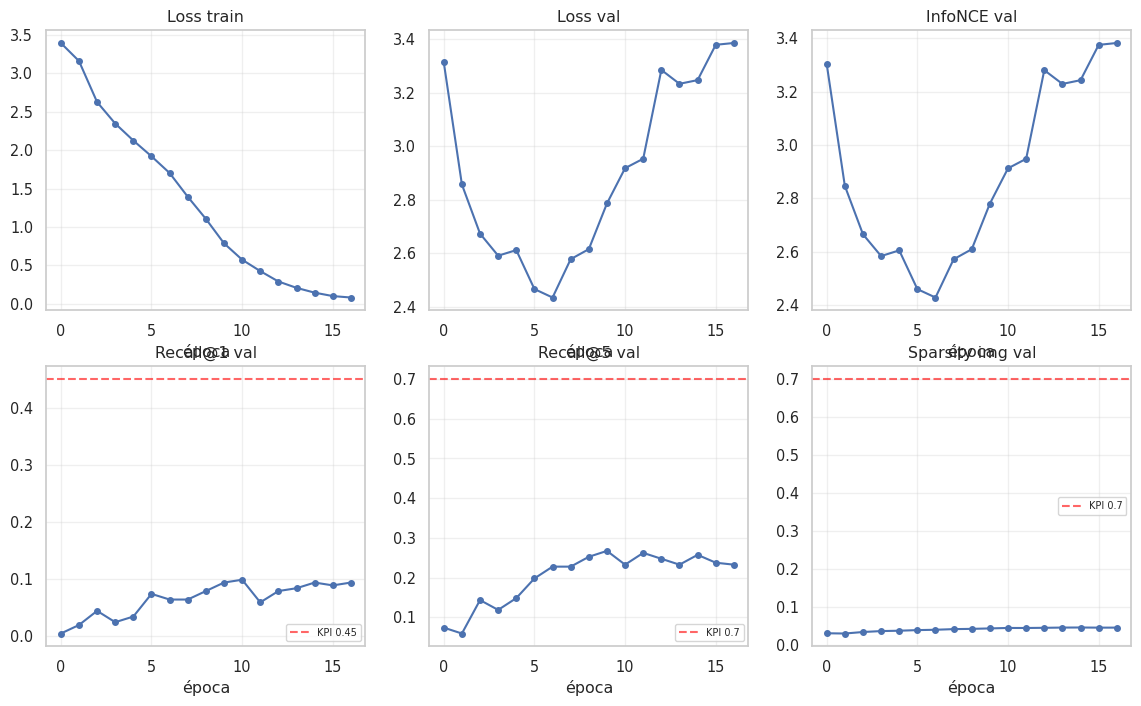

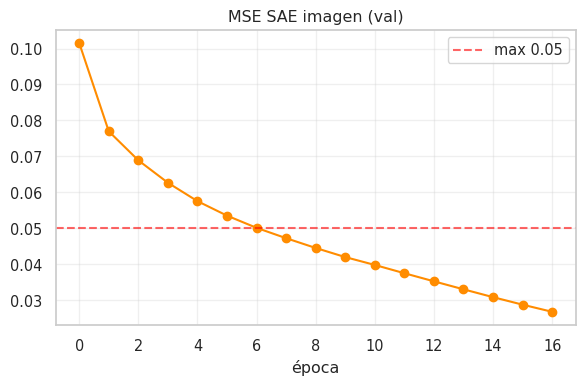

Guardado: /content/runs/sit2_clip_colab/curvas_diagnostico_val.png | /content/runs/sit2_clip_colab/curva_mse_sae_val.png


In [25]:
# @title Diagnóstico — curvas val (recall, infonce, sparsity, MSE)
import json
import matplotlib.pyplot as plt

def _col_train_loss(dfm):
    if "train/loss" in dfm.columns:
        return "train/loss"
    if "train/loss_epoch" in dfm.columns:
        return "train/loss_epoch"
    return None

hist = json.loads(Path(METRICS_JSON).read_text(encoding="utf-8"))
rows = hist.get("epochs", [])
if not rows:
    raise ValueError(f"No hay épocas en {METRICS_JSON}. Ejecuta primero el entrenamiento.")

dfm = pd.DataFrame(rows)
col_tl = _col_train_loss(dfm)
print("Mejor época (JSON):", hist.get("best"))
cols_show = ["epoch", "val/recall_at_1", "val/recall_at_5", "val/loss", "val/infonce",
             "val/sparsity_img", "val/mse_sae_img"]
if col_tl:
    cols_show.insert(4, col_tl)
cols_show = [c for c in cols_show if c in dfm.columns]
print(dfm[cols_show].round(4).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_specs = [
    (axes[0, 0], col_tl, "Loss train"),
    (axes[0, 1], "val/loss", "Loss val"),
    (axes[0, 2], "val/infonce", "InfoNCE val"),
    (axes[1, 0], "val/recall_at_1", "Recall@1 val", KPI_RECALL1_MIN),
    (axes[1, 1], "val/recall_at_5", "Recall@5 val", KPI_RECALL5_MIN),
    (axes[1, 2], "val/sparsity_img", "Sparsity img val", KPI_SPARSITY_MIN),
]
for ax, col, title, *kpi in plot_specs:
    if col and col in dfm.columns:
        ax.plot(dfm["epoch"], dfm[col], "o-", ms=4, lw=1.5)
    if kpi:
        ax.axhline(kpi[0], color="red", ls="--", alpha=0.6, label=f"KPI {kpi[0]}")
        ax.legend(fontsize=7)
    ax.set_title(title)
    ax.set_xlabel("época")
    ax.grid(True, alpha=0.3)

fig2, ax2 = plt.subplots(figsize=(6, 4))
if "val/mse_sae_img" in dfm.columns:
    ax2.plot(dfm["epoch"], dfm["val/mse_sae_img"], "o-", color="darkorange", lw=1.5)
    ax2.axhline(KPI_MSE_SAE_MAX, color="red", ls="--", alpha=0.6, label=f"max {KPI_MSE_SAE_MAX}")
    ax2.legend()
ax2.set_title("MSE SAE imagen (val)")
ax2.set_xlabel("época")
ax2.grid(True, alpha=0.3)
plt.tight_layout()

out_png = RUN_DIR / "curvas_diagnostico_val.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig2.savefig(RUN_DIR / "curva_mse_sae_val.png", dpi=150)
plt.show()
print("Guardado:", out_png, "|", RUN_DIR / "curva_mse_sae_val.png")


### Recall@1 global vs misma clase + matriz de confusión

- **Global:** texto correcto entre todos los de val (protocolo consigna).
- **Misma clase:** el texto correcto solo compite con textos de la **misma** clase (diagnóstico: ¿el modelo distingue clase o solo parecidos globales?).

Usa `embeddings_val_mejor.npz` del mejor Recall@1.


Recall@1 global (val, n=202): 0.0990
Recall@5 global:                  0.2327
Recall@1 misma clase (promedio):  0.0416  (por clase con n>=2)
  → Si misma clase >> global: textos muy parecidos entre clases.

Matriz confusión (clase verdadera × predicha por similitud img→txt):
predicha_top1           contaminacion_alta_NO2  contaminacion_alta_SO2  \
verdadera                                                                
contaminacion_alta_NO2                      24                       0   
contaminacion_alta_SO2                       5                      11   
ozono_anomalo                                4                       7   
vegetacion_densa                             3                       6   
suelo_urbano                                15                       4   

predicha_top1           ozono_anomalo  vegetacion_densa  suelo_urbano  
verdadera                                                              
contaminacion_alta_NO2              4                 4      

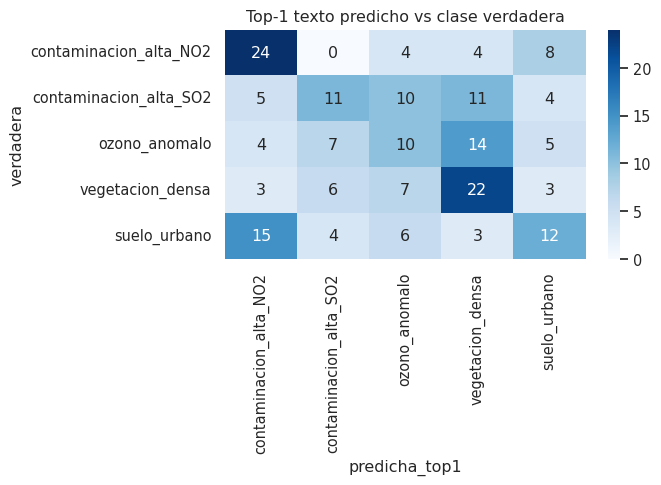

Guardado: /content/runs/sit2_clip_colab/matriz_confusion_clase.png | /content/runs/sit2_clip_colab/recall_global_vs_clase.csv


In [26]:
# @title Diagnóstico — Recall global vs misma clase + matriz confusión
import torch.nn.functional as F

def recall_at_k_masked(e_img, e_txt, k=1, mask=None):
    e_img = F.normalize(torch.as_tensor(e_img), dim=-1)
    e_txt = F.normalize(torch.as_tensor(e_txt), dim=-1)
    sim = e_img @ e_txt.T
    n = sim.shape[0]
    labels = torch.arange(n)
    if mask is not None:
        sim = sim.masked_fill(~mask, float("-inf"))
    kk = min(k, sim.shape[1])
    topk = sim.topk(kk, dim=1).indices
    return float((topk == labels.unsqueeze(1)).any(dim=1).float().mean().item())

def confusion_top1(e_img, e_txt, clases):
    e_img = F.normalize(torch.as_tensor(e_img), dim=-1)
    e_txt = F.normalize(torch.as_tensor(e_txt), dim=-1)
    pred_idx = (e_img @ e_txt.T).argmax(dim=1).numpy()
    pred_clase = [clases[int(j)] for j in pred_idx]
    mat = pd.crosstab(
        pd.Categorical(clases, categories=CLASES, ordered=True),
        pd.Categorical(pred_clase, categories=CLASES, ordered=True),
        rownames=["verdadera"], colnames=["predicha_top1"],
    ).reindex(index=CLASES, columns=CLASES, fill_value=0)
    return mat

emb_path = Path(EMBEDDINGS_BEST)
if not emb_path.is_file():
    raise FileNotFoundError(f"No existe {emb_path}. Entrena primero o ajusta EMBEDDINGS_BEST.")

emb = np.load(emb_path, allow_pickle=True)
e_img, e_txt = emb["e_img"], emb["e_txt"]
tile_ids = emb["tile_ids"].astype(str)
id2clase = df.set_index("tile_id")["clase"].to_dict()
clases_val = np.array([id2clase.get(tid, "") for tid in tile_ids])

r1_global = recall_at_k_image_to_text(torch.from_numpy(e_img), torch.from_numpy(e_txt), 1)
r5_global = recall_at_k_image_to_text(torch.from_numpy(e_img), torch.from_numpy(e_txt), 5)

r1_cls, n_eval = [], 0
clases_t = torch.as_tensor([CLASES.index(c) if c in CLASES else -1 for c in clases_val])
for ci, cname in enumerate(CLASES):
    idx = torch.where(clases_t == ci)[0]
    if len(idx) < 2:
        continue
    mask = torch.zeros(len(clases_val), len(clases_val), dtype=torch.bool)
    for i in idx:
        mask[i, idx] = True
    r1_cls.append(recall_at_k_masked(e_img, e_txt, 1, mask))
    n_eval += len(idx)
r1_misma_clase = float(np.mean(r1_cls)) if r1_cls else float("nan")

print(f"Recall@1 global (val, n={len(tile_ids)}): {r1_global:.4f}")
print(f"Recall@5 global:                  {r5_global:.4f}")
print(f"Recall@1 misma clase (promedio):  {r1_misma_clase:.4f}  (por clase con n>=2)")
print(f"  → Si misma clase >> global: textos muy parecidos entre clases.")

cm = confusion_top1(e_img, e_txt, clases_val)
print("\nMatriz confusión (clase verdadera × predicha por similitud img→txt):")
print(cm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Top-1 texto predicho vs clase verdadera")
plt.tight_layout()
out_cm = RUN_DIR / "matriz_confusion_clase.png"
plt.savefig(out_cm, dpi=150)
plt.show()
pd.DataFrame({
    "metrica": ["recall_at_1_global", "recall_at_5_global", "recall_at_1_misma_clase"],
    "valor": [r1_global, r5_global, r1_misma_clase],
}).to_csv(RUN_DIR / "recall_global_vs_clase.csv", index=False)
print("Guardado:", out_cm, "|", RUN_DIR / "recall_global_vs_clase.csv")


### Histograma de `z_img` (val, mejor checkpoint)

Distribución de activaciones del SAE visual. Si casi no hay masa cerca de 0, subir λ no alcanzará sparsity 0.70 sin ReLU/top-k.


|z| < 0.01: 0.0442  (KPI sparsity ≈ 4.42%, meta ≥ 0.7)
z: mean=0.0072 std=0.1867 min=-0.6705 max=0.7345


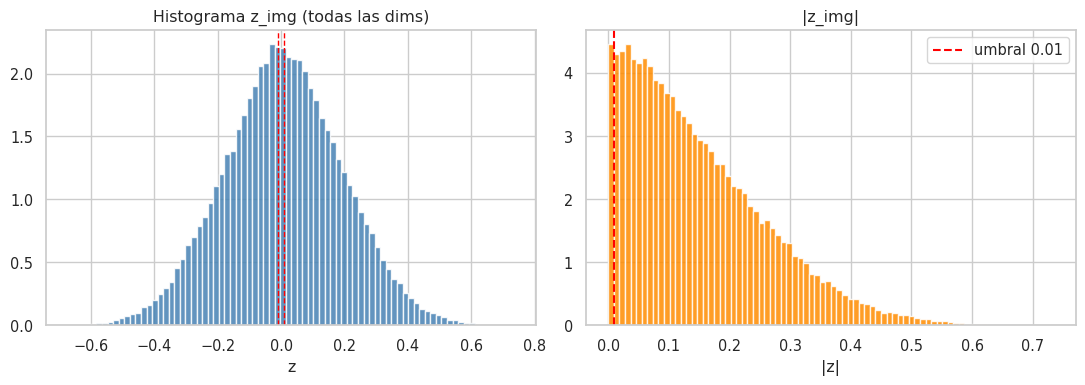

  λ=1e-04 → sparsity actual ~0.044 (subir λ empuja |z|→0 solo si re-entrenas)
  λ=1e-03 → sparsity actual ~0.044 (subir λ empuja |z|→0 solo si re-entrenas)
  λ=1e-02 → sparsity actual ~0.044 (subir λ empuja |z|→0 solo si re-entrenas)
  λ=1e-01 → sparsity actual ~0.044 (subir λ empuja |z|→0 solo si re-entrenas)
Guardado: /content/runs/sit2_clip_colab/histograma_z_img_val.png


In [27]:
# @title Diagnóstico — histograma z_img (val)
emb = np.load(EMBEDDINGS_BEST, allow_pickle=True)
z = emb["z_img"].astype(np.float64).ravel()
thr = 0.01
frac_below = float((np.abs(z) < thr).mean())
print(f"|z| < {thr}: {frac_below:.4f}  (KPI sparsity ≈ {frac_below:.2%}, meta ≥ {KPI_SPARSITY_MIN})")
print(f"z: mean={z.mean():.4f} std={z.std():.4f} min={z.min():.4f} max={z.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(z, bins=80, color="steelblue", alpha=0.85, density=True)
axes[0].axvline(-thr, color="red", ls="--", lw=1)
axes[0].axvline(thr, color="red", ls="--", lw=1)
axes[0].set_title("Histograma z_img (todas las dims)")
axes[0].set_xlabel("z")

axes[1].hist(np.abs(z), bins=80, color="darkorange", alpha=0.85, density=True)
axes[1].axvline(thr, color="red", ls="--", label=f"umbral {thr}")
axes[1].set_title("|z_img|")
axes[1].set_xlabel("|z|")
axes[1].legend()
plt.tight_layout()
out_h = RUN_DIR / "histograma_z_img_val.png"
plt.savefig(out_h, dpi=150)
plt.show()

# Porcentaje bajo umbral vs lambda (teórico, sin re-entrenar)
for lam in [1e-4, 1e-3, 1e-2, 1e-1]:
    print(f"  λ={lam:.0e} → sparsity actual ~{frac_below:.3f} (subir λ empuja |z|→0 solo si re-entrenas)")

print("Guardado:", out_h)


### 20 tiles con peor similitud imagen → su texto correcto

Ordenados por coseno entre `e_img[i]` y `e_txt[i]`. Ayuda a separar **error de dato** (nube, NDVI raro) vs **error de modelo**.


 rank                                              tile_id  cos_diag                  clase  frac_nubes_scl  frac_claros_scl     ndvi                                                                                                               descripcion
    1 20210210T153619_20210210T153617_T18NUJ__y3232__x1472 -0.113544       vegetacion_densa        0.059326         0.940674 0.521506 Tile Sentinel-2 sobre Cali con vegetacion densa y baja contaminacion (2021-02-10, lat=3.3568, lon=-76.5149, NDVI=0.52, B…
    2 20230620T153619_20230620T153915_T18NUK__y0320__x2720 -0.109364           suelo_urbano        0.062500         0.937500 0.589628 Tile Sentinel-2 sobre Cali con cobertura urbana de suelo expuesto (2023-06-20, lat=3.6184, lon=-76.4027, NDVI=0.59, BSI=…
    3 20231127T153619_20231127T153621_T18NUJ__y1408__x1888 -0.109225 contaminacion_alta_NO2        0.000000         1.000000 0.589121 Tile Sentinel-2 sobre Cali con concentracion alta de NO2 troposferico (2023-11-27, lat=3.5206, lon

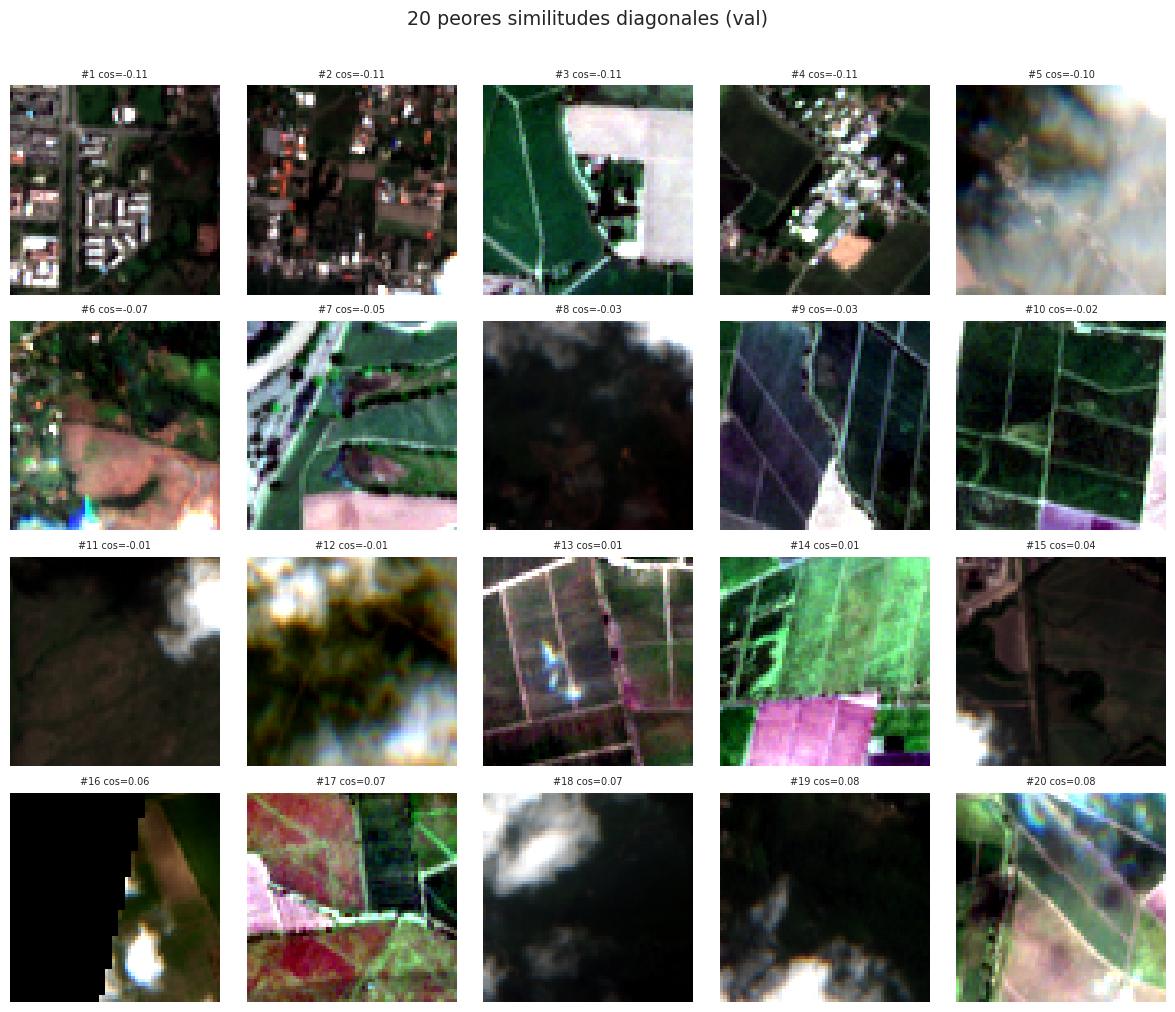

Guardado: /content/runs/sit2_clip_colab/panel_peores_20_val.png


In [28]:
# @title Diagnóstico — 20 peores pares img→txt (val)
import torch.nn.functional as F

emb = np.load(EMBEDDINGS_BEST, allow_pickle=True)
e_img = F.normalize(torch.from_numpy(emb["e_img"]), dim=-1)
e_txt = F.normalize(torch.from_numpy(emb["e_txt"]), dim=-1)
tile_ids = emb["tile_ids"].astype(str)
diag = (e_img * e_txt).sum(dim=1).numpy()

meta_val = df[df["split"] == "val"].set_index("tile_id")
rows_worst = []
for rank, i in enumerate(np.argsort(diag)[:20]):
    tid = tile_ids[i]
    m = meta_val.loc[tid] if tid in meta_val.index else None
    rows_worst.append({
        "rank": rank + 1,
        "tile_id": tid,
        "cos_diag": float(diag[i]),
        "clase": str(m["clase"]) if m is not None else "",
        "frac_nubes_scl": float(m["frac_nubes_scl"]) if m is not None else np.nan,
        "frac_claros_scl": float(m["frac_claros_scl"]) if m is not None else np.nan,
        "ndvi": float(m["ndvi"]) if m is not None else np.nan,
        "descripcion": (str(m["descripcion"])[:120] + "…") if m is not None else "",
    })
worst_df = pd.DataFrame(rows_worst)
out_w = RUN_DIR / "peores_20_pares_val.csv"
worst_df.to_csv(out_w, index=False)
print(worst_df.to_string(index=False))
print("\nGuardado:", out_w)

# Panel visual 4x5
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for k, ax in enumerate(axes.ravel()):
    if k >= len(worst_df):
        ax.axis("off")
        continue
    tid = worst_df.iloc[k]["tile_id"]
    j = int(df.index[df["tile_id"] == tid][0])
    tile = np.asarray(tiles_z[j])
    ax.imshow(tile_to_rgb_uint8(tile))
    ax.set_title(f"#{worst_df.iloc[k]['rank']} cos={worst_df.iloc[k]['cos_diag']:.2f}", fontsize=7)
    ax.axis("off")
plt.suptitle("20 peores similitudes diagonales (val)", y=1.01)
plt.tight_layout()
out_p = RUN_DIR / "panel_peores_20_val.png"
plt.savefig(out_p, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", out_p)


### Ablación mental: α (SAE) y λ (L1)

Tabla de referencia **sin re-entrenar** aquí. Para experimentos reales, duplica hiperparámetros en la celda de configuración y vuelve a entrenar.

| Escenario | Efecto esperado |
|-----------|-----------------|
| α = 0 (solo InfoNCE) | Techo de Recall; MSE/sparsity SAE dejan de optimizarse en el loss total |
| λ ↑ (p. ej. 1e-2) | Más \|z\| pequeños → sube sparsity; suele bajar Recall y subir MSE reconstrucción |
| α = 0.1, λ = 1e-3 (actual) | Compromiso actual: buen Recall relativo, sparsity ~4% |


In [29]:
# @title Diagnóstico — tabla ablacion (referencia + estado actual)
ablacion = pd.DataFrame([
    {"escenario": "actual", "alpha_sae": ALPHA_SAE, "lambda_l1": LAMBDA_L1,
     "nota": "Config en celda de entrenamiento"},
    {"escenario": "solo_infonce", "alpha_sae": 0.0, "lambda_l1": LAMBDA_L1,
     "nota": "Techo Recall; desactiva peso SAE en loss"},
    {"escenario": "lambda_alto", "alpha_sae": ALPHA_SAE, "lambda_l1": 1e-2,
     "nota": "Más sparsity, Recall suele caer"},
    {"escenario": "lambda_muy_alto", "alpha_sae": ALPHA_SAE, "lambda_l1": 1e-1,
     "nota": "Sparsity alta; riesgo MSE > 0.05"},
])
print(ablacion.to_string(index=False))

if Path(METRICS_JSON).is_file():
    best = json.loads(Path(METRICS_JSON).read_text(encoding="utf-8")).get("best", {})
    print("\nMejor época registrada:")
    for k in ["epoch", "val/recall_at_1", "val/recall_at_5", "val/sparsity_img", "val/mse_sae_img"]:
        if k in best:
            print(f"  {k}: {best[k]}")
else:
    print("\n(Sin metricas_por_epoca.json aún)")

ablacion.to_csv(RUN_DIR / "tabla_ablacion_referencia.csv", index=False)
print("\nPara correr ablación real: cambia ALPHA_SAE / LAMBDA_L1 y re-ejecuta entrenamiento.")


      escenario  alpha_sae  lambda_l1                                     nota
         actual        0.1      0.001         Config en celda de entrenamiento
   solo_infonce        0.0      0.001 Techo Recall; desactiva peso SAE en loss
    lambda_alto        0.1      0.010          Más sparsity, Recall suele caer
lambda_muy_alto        0.1      0.100         Sparsity alta; riesgo MSE > 0.05

Mejor época registrada:
  epoch: 10
  val/recall_at_1: 0.09901
  val/recall_at_5: 0.232673
  val/sparsity_img: 0.044197
  val/mse_sae_img: 0.039828

Para correr ablación real: cambia ALPHA_SAE / LAMBDA_L1 y re-ejecuta entrenamiento.


## KPIs consigna (referencia en **val**)

| Métrica | Mínimo | Excelente |
|---------|--------|-----------|
| Recall@1 | 0.45 | 0.65 |
| Recall@5 | 0.70 | 0.85 |
| Sparsity SAE img | 0.70 | 0.85 |
| MSE SAE | ≤ 0.05 | ≤ 0.02 |

Test split (203) reservado para evaluación final fuera de este entrenamiento.

In [30]:
# @title Guardar checkpoint final
import hashlib

ckpt_path = RUN_DIR / "checkpoint.pt"
best = ckpt_cb.best_model_path if ckpt_cb.best_model_path else None
if best:
    lit_save = LitGeoVisionClipSAE()
    lit_save.load_state_dict(torch.load(best, map_location="cpu")["state_dict"])
else:
    lit_save = lit

bundle = {
    "state_dict": lit_save.model.state_dict(),
    "band_mean": band_mean.tolist(),
    "band_std": band_std.tolist(),
    "hparams": {"lr": LR, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS, "seed": SEED},
    "best_checkpoint": str(best or ""),
}
torch.save(bundle, ckpt_path)
h = hashlib.md5(ckpt_path.read_bytes()).hexdigest()
(ckpt_path.with_suffix(".pt.md5")).write_text(h + "\n", encoding="utf-8")
print("Checkpoint:", ckpt_path, "| MD5:", h)
if best:
    print("Pesos desde:", best)


ViT-B-32 descargado en: /content/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


load_state_dict: <All keys matched successfully>
OK: RemoteCLIP visual (ViT-B-32) listo.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint: /content/runs/sit2_clip_colab/checkpoint.pt | MD5: 69d586d8c7ec2a757102fa4491e72ce7
Pesos desde: /content/runs/sit2_clip_colab/checkpoints/best-epoch=10-r1val/recall_at_1=0.099.ckpt
